In [1]:
import os
import glob

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [2]:
DATA_DIR = "/n/groups/kirschner/Wills_rna_seq"

result_fps = glob.glob(os.path.join(DATA_DIR, "aligned", "hg38_knownGene", "*", "*", "STAR_out", "ReadsPerGene.out.tab"))
result_fps

['/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_S35_LL9464_S19/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_S22_LL9464_S13/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_S30_LL9464_S16/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_S40_LL9464_S20/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_S27_LL9464_S15/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_20S_LL9464_S12/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_S25_LL9464_S14/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/aligned/hg38_knownGene/SubQ/20220114_S19_LL9464_S11/STAR_out/ReadsPerGene.out.tab',
 '/n/groups/kirschner/Wills_rna_seq/alig

In [3]:
gene_counts = {}

for result_fp in result_fps:
    data = pd.read_csv(result_fp, sep="\t", skiprows=4, header=None, index_col=0)
    sample_type = Path(result_fp).parts[-4]
    sample_name = Path(result_fp).parts[-3].split("_")[1]
    sample_type_name = f"{sample_type}_{sample_name}"
    print(sample_type_name)
    gene_counts[sample_type_name] = data.loc[:,1]

SubQ_S35
SubQ_S22
SubQ_S30
SubQ_S40
SubQ_S27
SubQ_20S
SubQ_S25
SubQ_S19
SubQ_S34
SubQ_S33
Liver_20L
Liver_L33
Liver_L22
Liver_L19
Liver_L40
Liver_L27
Liver_30L
Liver_L25
Liver_L34
Liver_35L
Omentum_O30
Omentum_O40
Omentum_O27
Omentum_O33
Omentum_O35
Omentum_O20
Omentum_O34
Omentum_O19
Omentum_O25
Omentum_O22


In [4]:
gene_counts_df = pd.DataFrame(gene_counts).T
gene_counts_df

,ENST00000456328.2,ENST00000619216.1,ENST00000473358.1,ENST00000469289.1,ENST00000607096.1,ENST00000417324.1,ENST00000461467.1,ENST00000642116.1,ENST00000641515.2,ENST00000466430.5,...,ENST00000420810.1,ENST00000456738.1,ENST00000435945.1,ENST00000435741.1,ENST00000431853.1,ENST00000412936.6_2,ENST00000422618.6_2,ENST00000456370.6_2,ENST00000421233.6_2,ENST00000507418.6_2
SubQ_S35,0,0,0,0,0,0,0,0,0,5,...,0,1,2,0,0,0,0,0,0,0
SubQ_S22,16,1,9,0,0,2,0,12,3,4,...,3,0,32,0,21,0,0,0,0,0
SubQ_S30,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
SubQ_S40,0,0,0,0,0,5,0,0,0,1,...,0,0,7,0,0,0,0,0,0,0
SubQ_S27,29,0,3,0,0,6,0,6,14,3,...,0,1,0,0,25,0,0,0,0,0
SubQ_20S,6,0,6,4,0,14,0,0,3,3,...,1,3,23,5,24,0,0,0,0,0
SubQ_S25,12,0,14,2,0,9,0,4,0,1,...,0,0,0,0,13,0,0,0,0,0
SubQ_S19,5,0,5,1,0,0,0,1,0,0,...,0,7,5,0,1,0,0,0,0,0
SubQ_S34,25,4,11,1,0,17,0,6,1,3,...,0,0,0,0,35,0,0,0,0,0
SubQ_S33,17,0,4,0,0,9,0,9,17,15,...,7,11,26,1,31,0,0,0,0,0


In [5]:
gene_counts_df.sum(axis=1)

SubQ_S35        6644917
SubQ_S22        1279180
SubQ_S30        5238557
SubQ_S40       18998158
SubQ_S27        1309864
SubQ_20S        1968808
SubQ_S25         921377
SubQ_S19        4884254
SubQ_S34        1386330
SubQ_S33         861729
Liver_20L       2016498
Liver_L33       3139033
Liver_L22      17933202
Liver_L19      13919307
Liver_L40       6291414
Liver_L27       9260162
Liver_30L       3723528
Liver_L25      14291579
Liver_L34      12757426
Liver_35L       3823133
Omentum_O30    13155515
Omentum_O40     1185400
Omentum_O27      886421
Omentum_O33      880464
Omentum_O35     9448054
Omentum_O20     8865020
Omentum_O34      618198
Omentum_O19      544838
Omentum_O25      623336
Omentum_O22     3985325
dtype: int64

In [6]:
min_gene_counts = 10

gene_counts_df.shape[1], (gene_counts_df.sum(axis=0) > min_gene_counts).sum()

(269217, 118894)

In [7]:
gene_counts_df = gene_counts_df.loc[:, gene_counts_df.sum(axis=0) > min_gene_counts]

In [8]:
patient_metadata = pd.read_csv(os.path.join(DATA_DIR, "metadata.tsv"), sep="\t")
patient_metadata

,Patient ID,Sex,Grouping
0,P22,M,Ob
1,P33,M,Ob
2,P34,F,Ob
3,P19,F,Ob
4,P35,F,Ob
5,P30,F,Ob+T2D
6,P20,M,Ob+T2D
7,P25,F,Ob+T2D
8,P27,F,Ob+T2D
9,P40,M,Ob+T2D


In [9]:
metadata = pd.DataFrame({sample_name: sample_name.split("_")[0] for sample_name in gene_counts_df.index}, index=["organ",]).T
metadata

,organ
SubQ_S35,SubQ
SubQ_S22,SubQ
SubQ_S30,SubQ
SubQ_S40,SubQ
SubQ_S27,SubQ
SubQ_20S,SubQ
SubQ_S25,SubQ
SubQ_S19,SubQ
SubQ_S34,SubQ
SubQ_S33,SubQ


In [10]:
metadata["patient_id"] = metadata.index.to_series().str.extract("(\d+)")
patient_metadata["patient_id"] = patient_metadata["Patient ID"].str.extract("(\d+)")
patient_metadata.set_index("patient_id", inplace=True)

In [11]:
cols = ["Sex", "Grouping"]

for col in cols:
    metadata[col] = [patient_metadata.loc[pid, col] for pid in metadata.patient_id.values]

In [12]:
metadata

,organ,patient_id,Sex,Grouping
SubQ_S35,SubQ,35,F,Ob
SubQ_S22,SubQ,22,M,Ob
SubQ_S30,SubQ,30,F,Ob+T2D
SubQ_S40,SubQ,40,M,Ob+T2D
SubQ_S27,SubQ,27,F,Ob+T2D
SubQ_20S,SubQ,20,M,Ob+T2D
SubQ_S25,SubQ,25,F,Ob+T2D
SubQ_S19,SubQ,19,F,Ob
SubQ_S34,SubQ,34,F,Ob
SubQ_S33,SubQ,33,M,Ob


In [13]:
dds = DeseqDataSet(
    counts=gene_counts_df,
    metadata=metadata,
    design_factors=["organ", "Sex", "Grouping"],
    refit_cooks=True,
    n_cpus=3,
)

In [14]:
dds.deseq2()

Fitting size factors...
... done in 0.19 seconds.

Fitting dispersions...
... done in 79.06 seconds.

Fitting dispersion trend curve...
... done in 36.59 seconds.

Fitting MAP dispersions...
... done in 77.83 seconds.

Fitting LFCs...
... done in 92.02 seconds.

Refitting 505 outliers.

Fitting dispersions...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 0.32 seconds.

Fitting LFCs...
... done in 0.61 seconds.



In [15]:
dds.vst()

Fitting dispersions...
... done in 70.39 seconds.

Fitting dispersion trend curve...
... done in 36.45 seconds.



In [16]:
dds.layers["vst_counts"].shape

(30, 118894)

In [17]:
dds.var_names.rename("transcript_id", inplace=True)

In [18]:
dds.varm

AxisArrays with keys: non_zero, _rough_dispersions, genewise_dispersions, _genewise_converged, _normed_means, fitted_dispersions, MAP_dispersions, _MAP_converged, dispersions, _outlier_genes, LFC, _LFC_converged, replaced

In [19]:
dds.uns.keys()

odict_keys(['trend_coeffs', '_squared_logres', 'prior_disp_var'])

In [20]:
dds.uns["trend_coeffs"].values

array([0.77433445, 3.46087657])

In [21]:
# backup
dds_backup = dds.copy()
dds_backup.uns["trend_coeffs"] = dds_backup.uns["trend_coeffs"].values
dds_backup.write(os.path.join(DATA_DIR, "dds.h5ad"))

In [14]:
import anndata as ad

dds = ad.read_h5ad(os.path.join(DATA_DIR, "dds.h5ad"))
dds

AnnData object with n_obs × n_vars = 30 × 118894
    obs: 'organ', 'patient_id', 'Sex', 'Grouping'
    uns: '_squared_logres', 'prior_disp_var', 'trend_coeffs'
    obsm: 'design_matrix', 'replaceable', 'size_factors'
    varm: 'LFC', 'MAP_dispersions', '_LFC_converged', '_MAP_converged', '_genewise_converged', '_normed_means', '_outlier_genes', '_rough_dispersions', 'dispersions', 'fitted_dispersions', 'genewise_dispersions', 'non_zero', 'replaced'
    layers: '_hat_diagonals', '_mu_LFC', '_mu_hat', 'cooks', 'normed_counts', 'replace_cooks', 'vst_counts'

In [22]:
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [25]:
dds.layers["vst_counts"].shape

(30, 118894)

In [29]:
data_scaled = StandardScaler().fit_transform(dds.layers["vst_counts"])

pca = PCA(n_components=3)
coords = pca.fit_transform(data_scaled)

coords.shape

(30, 3)

In [30]:
assert (dds.obs_names == metadata.index).all()

In [31]:
metadata["coverage"] = gene_counts_df.sum(axis=1)

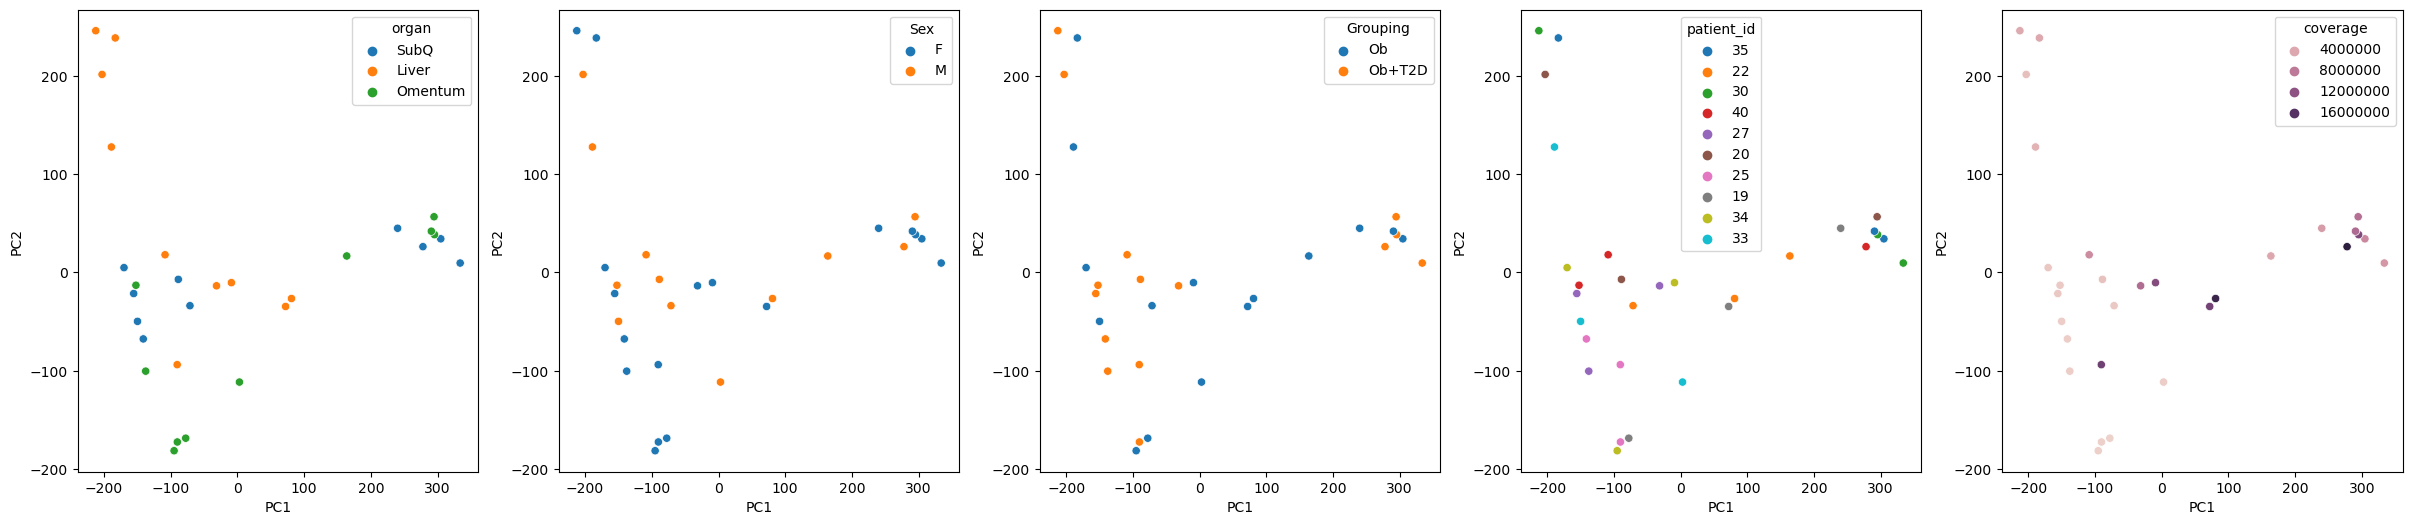

In [32]:
hues = ["organ", "Sex", "Grouping", "patient_id", "coverage"]
fig, axs = plt.subplots(1, len(hues), figsize=(len(hues)*6, 6), dpi=100)

for i, hue in enumerate(hues):
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=metadata[hue], ax=axs[i])
    axs[i].set_xlabel("PC1")
    axs[i].set_ylabel("PC2")

Text(0, 0.5, 'PC3')

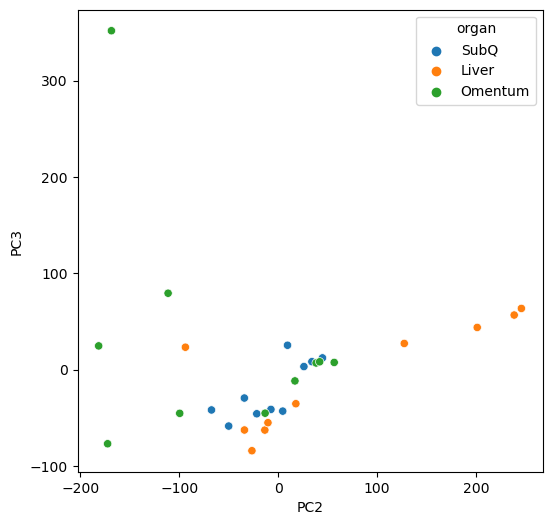

In [20]:
fig, ax = plt.subplots(figsize=(6,6), dpi=100)
sns.scatterplot(x=coords[:,1], y=coords[:,2], hue=metadata.organ, ax=ax)
ax.set_xlabel("PC2")
ax.set_ylabel("PC3")

In [27]:
import sklearn

dist = sklearn.metrics.pairwise.cosine_distances(dds.layers["vst_counts"], dds.layers["vst_counts"])
dist.shape

(30, 30)

In [33]:
dist_df = pd.DataFrame(dist, columns=metadata.index, index=metadata.index)

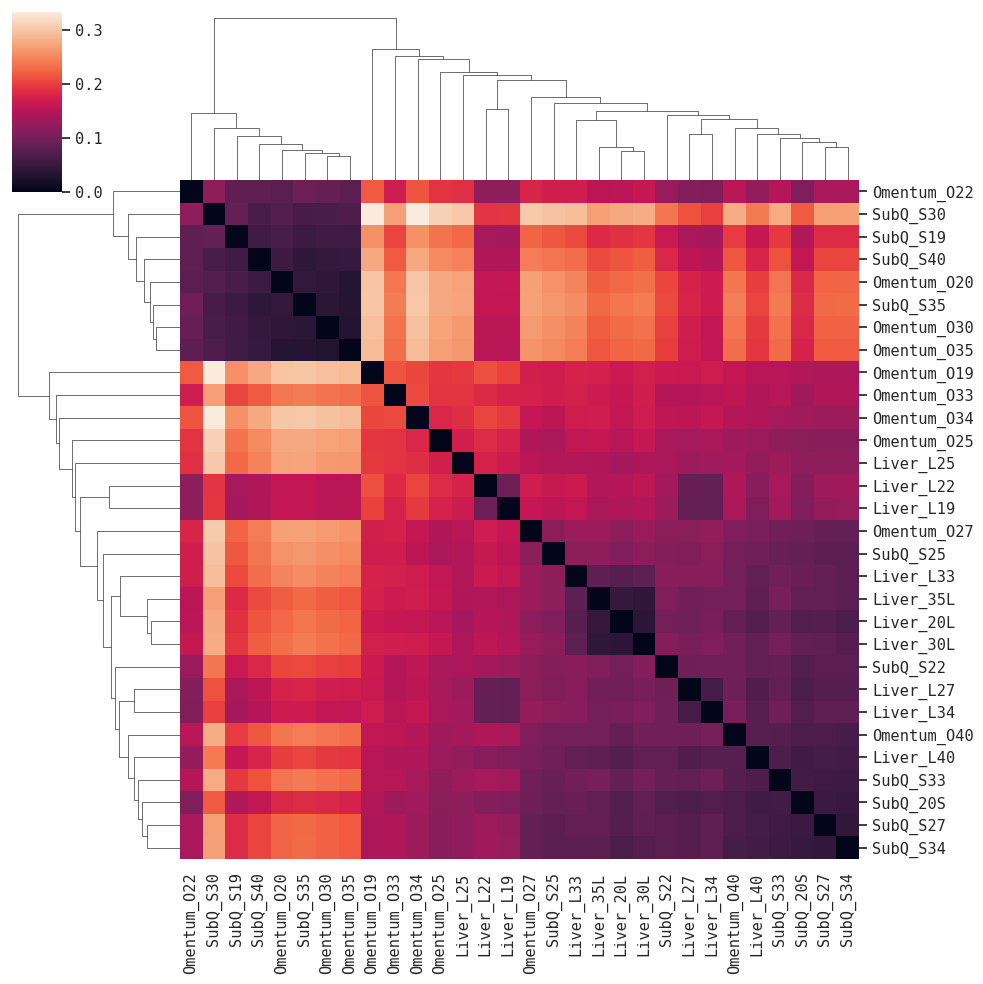

In [35]:
import scipy.spatial as sp, scipy.cluster.hierarchy as hc

sns.set(font="monospace")

# DF_corr = DF.T.corr()
# DF_dism = 1 - DF_corr   # distance matrix

linkage = hc.linkage(sp.distance.squareform(dist_df), method='average')
g = sns.clustermap(dist_df, row_linkage=linkage, col_linkage=linkage)

# plt.setp(metadata.index, rotation=0)  # For y axis
# plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90) # For x axis